In [ ]:
from tradepy.target import create_targets, create_targets_atr, apply_liquidity_filter, audit_single_df, evaluate_atr_multipliers
from tradepy.models import prepare_all, run_gold_master_workflow, create_lstm_dataset, apply_confidence_filter, sweep_confidence_thresholds
import numpy as np
import torch.nn as nn
import torch
from tqdm import tqdm
from sklearn.preprocessing import RobustScaler
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd


In [ ]:
asset_list = ["bp1", "cl1", "es1", "gc1"]
ASSET = asset_list[3]
MINUTES = 60
RETURN_HORIZON_MIN  = MINUTES * 2

In [ ]:
df_final, spec = prepare_all(ASSET, MINUTES, RETURN_HORIZON_MIN, json_config_path="../Features/features_config.json")

Dataset 'gc1' imported with 4565856 rows
Limpieza gc1 completada. Filas restantes: 4456388


In [ ]:
# Columnas a excluir siempre
exclude_cols_bin = [
    # Identificadores / temporales no cíclicos
    "datetime", "dtyyyymmdd", "trading_date", "ticker", "per", "openint",

    # OHLCV raw (el modelo no debería ver precios absolutos)
    "open", "high", "low", "close", "volume",

    # Targets
    "target_bin", "target_class", f"target_logret_{MINUTES}", f"target_ret_{MINUTES}", f"target_ticks_{MINUTES}"
]

feature_cols_bin = [c for c in df_final.columns if c not in exclude_cols_bin]
exclude_cols_triple = [
    # Identificadores / temporales no cíclicos
    "datetime", "dtyyyymmdd", "trading_date", "ticker", "per", "openint",

    # OHLCV raw (el modelo no debería ver precios absolutos)
    "open", "high", "low", "close", "volume",

    # Targets
    "target_bin", f"target_logret_{MINUTES}", f"target_ret_{MINUTES}", f"target_ticks_{MINUTES}"
]

feature_cols_triple = [c for c in df_final.columns if c not in exclude_cols_triple]


In [ ]:
df_final_bin = create_targets(df_final, return_horizon_min=RETURN_HORIZON_MIN, sampling_minutes=MINUTES, tick_size=spec['tick_size'], threshold_buy=20)
print(df_final_bin.target_bin.sum() / df_final_bin['datetime'].dt.date.nunique())

4.1623762376237625


In [ ]:
df_final_triple = create_targets(df_final, return_horizon_min=RETURN_HORIZON_MIN, sampling_minutes=MINUTES, tick_size=spec['tick_size'], threshold_buy=25 , threshold_sell=25, ternary=True)
print(len(df_final_triple[df_final_triple.target_class == 2]) / df_final_triple['datetime'].dt.date.nunique())
print(len(df_final_triple[df_final_triple.target_class == 0]) / df_final_triple['datetime'].dt.date.nunique())

3.3804455445544552
3.2935643564356436


In [ ]:
evaluate_atr_multipliers(df_final, return_horizon_min=RETURN_HORIZON_MIN, sampling_minutes=MINUTES, tick_size=spec['tick_size'], atr_min=0.5, atr_max=2.0, atr_step=0.25)

,atr_multiplier,target_class,count_before,count_after,norm_before,norm_after
0,0.50,0.0,18206,10100,0.237249,0.131617
1,0.50,1.0,40115,56201,0.522753,0.732375
2,0.50,2.0,18417,10437,0.239998,0.136008
3,0.75,0.0,12187,6925,0.158813,0.090242
4,0.75,1.0,52192,62698,0.680132,0.817040
5,0.75,2.0,12359,7115,0.161054,0.092718
6,1.00,0.0,8323,4919,0.108460,0.064101
7,1.00,1.0,60016,66779,0.782090,0.870221
8,1.00,2.0,8399,5040,0.109450,0.065678
9,1.25,0.0,5817,3583,0.075803,0.046691


In [ ]:
df_final_bin_atr = create_targets_atr(df_final, return_horizon_min=RETURN_HORIZON_MIN, sampling_minutes=MINUTES, tick_size=spec['tick_size'], ternary=False, atr_multiplier=1.5)
print(df_final_bin_atr.target_bin.sum() / df_final_bin_atr['datetime'].dt.date.nunique())

1.0133663366336634


In [ ]:
df_final_triple_atr = create_targets_atr(df_final, return_horizon_min=RETURN_HORIZON_MIN, sampling_minutes=MINUTES, tick_size=spec['tick_size'], ternary=True, atr_multiplier=0.75)
print(len(df_final_triple_atr[df_final_triple_atr.target_class == 2]) / df_final_triple_atr['datetime'].dt.date.nunique())
print(len(df_final_triple_atr[df_final_triple_atr.target_class == 0]) / df_final_triple_atr['datetime'].dt.date.nunique())

3.0591584158415843
3.0165841584158417


In [ ]:
df_final_triple_liquid = apply_liquidity_filter(df_final_triple_atr)
print(len(df_final_triple_liquid[df_final_triple_liquid.target_class == 2]) / df_final_triple_liquid['datetime'].dt.date.nunique())
print(len(df_final_triple_liquid[df_final_triple_liquid.target_class == 0]) / df_final_triple_liquid['datetime'].dt.date.nunique())

1.761138613861386
1.7141089108910892


In [ ]:
df_final_triple_liquid = audit_single_df(df_final_triple_liquid, feature_cols_triple)

💎 Sin NaNs en features


In [ ]:
TARGET_COLUMN_BIN = 'target_bin' # 1 si sube, 0 si baja/lateral
TARGET_COLUMN_TRIPLE = 'target_class' # 2 si sube, 1 si lateral, 0 si baja

In [ ]:
class GoldLSTM_Triple_Pro(nn.Module):
    def __init__(self, input_dim, output_dim=3, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        # Usamos batch_first=True para que coincida con tu create_lstm_dataset
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        
        # Capas densas con Dropout para evitar overfitting en el Oro
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )

    def forward(self, x):
        # x shape: (batch, lookback, features)
        lstm_out, (hn, cn) = self.lstm(x)
        
        # Tomamos el último estado oculto de la última capa
        # hn[-1] shape: (batch, hidden_dim)
        return self.head(hn[-1])

In [ ]:
# result_triple, model_triple, sc_triple = run_gold_master_workflow(df_final_triple_liquid, feature_cols_triple, suffix=RETURN_HORIZON_MIN, model_class=GoldLSTM_Triple_Pro, target_col=TARGET_COLUMN_TRIPLE, train_size=20000, test_size=1000, step=500, lookback=48, batch_size=2048)

In [ ]:
# =========================
# MODELOS
# =========================

class GoldLSTM_Opportunity(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, 2, batch_first=True, dropout=0.3)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        return self.head(hn[-1])


class GoldLSTM_Direction(nn.Module):
    def __init__(self, input_dim, hidden_dim=128):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, 2, batch_first=True, dropout=0.3)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        return self.head(hn[-1])


# =========================
# EARLY STOPPING (CUSTOM)
# =========================

class EarlyStopping:
    def __init__(self, patience=3):
        self.patience = patience
        self.best_score = -np.inf
        self.counter = 0

    def step(self, score):
        if score > self.best_score:
            self.best_score = score
            self.counter = 0
            return False  # continue
        else:
            self.counter += 1
            return self.counter >= self.patience


# =========================
# WORKFLOW PRO
# =========================

def run_gold_dual_model_pro(
    df,
    feature_cols,
    suffix,
    train_size=40000,
    val_size=5000,
    test_size=5000,
    step=5000,
    lookback=48,
    epochs=20,
    batch_size=512,
):
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    scaler_amp = torch.amp.GradScaler(device.type)

    df = df.sort_values("datetime").reset_index(drop=True)
    results = []

    for start in tqdm(range(0, len(df) - train_size - val_size - test_size, step)):

        # ================= SPLIT =================
        train = df.iloc[start:start+train_size].copy()
        val   = df.iloc[start+train_size:start+train_size+val_size].copy()
        test  = df.iloc[start+train_size+val_size:start+train_size+val_size+test_size].copy()

        # ================= TARGETS =================
        for d in [train, val, test]:
            d["target_A"] = (d["target_class"] != 1).astype(int)

        train_B = train[train["target_class"] != 1].copy()
        val_B   = val[val["target_class"] != 1].copy()
        test_B  = test[test["target_class"] != 1].copy()

        for d in [train_B, val_B, test_B]:
            d["target_B"] = d["target_class"].map({0:0, 2:1})

        # ================= SCALING =================
        sc = RobustScaler()
        train[feature_cols] = sc.fit_transform(train[feature_cols])
        val[feature_cols]   = sc.transform(val[feature_cols])
        test[feature_cols]  = sc.transform(test[feature_cols])

        train_B[feature_cols] = sc.transform(train_B[feature_cols])
        val_B[feature_cols]   = sc.transform(val_B[feature_cols])
        test_B[feature_cols]  = sc.transform(test_B[feature_cols])

        # ================= DATA =================
        def make(df_, target):
            X, y = create_lstm_dataset(df_, feature_cols, target, lookback)
            return torch.tensor(X, dtype=torch.float32), torch.tensor(y)

        Xtr_A, ytr_A = make(train, "target_A")
        Xva_A, yva_A = make(val, "target_A")
        Xte_A, yte_A = make(test, "target_A")

        Xtr_B, ytr_B = make(train_B, "target_B")
        Xva_B, yva_B = make(val_B, "target_B")

        Xtr_A, ytr_A = Xtr_A.to(device), ytr_A.float().unsqueeze(1).to(device)
        Xva_A = Xva_A.to(device)
        Xte_A = Xte_A.to(device)

        Xtr_B, ytr_B = Xtr_B.to(device), ytr_B.long().to(device)
        Xva_B = Xva_B.to(device)

        loader_A = DataLoader(TensorDataset(Xtr_A, ytr_A), batch_size=batch_size, shuffle=True)
        loader_B = DataLoader(TensorDataset(Xtr_B, ytr_B), batch_size=batch_size, shuffle=True)

        # ================= MODELOS =================
        model_A = GoldLSTM_Opportunity(len(feature_cols)).to(device)
        model_B = GoldLSTM_Direction(len(feature_cols)).to(device)

        opt_A = optim.Adam(model_A.parameters(), lr=5e-4)
        opt_B = optim.Adam(model_B.parameters(), lr=5e-4)

        crit_A = nn.BCEWithLogitsLoss()
        crit_B = nn.CrossEntropyLoss()

        early_A = EarlyStopping(3)
        early_B = EarlyStopping(3)

        # ================= TRAIN LOOP =================
        for epoch in range(epochs):

            # ---- TRAIN A ----
            model_A.train()
            for bx, by in loader_A:
                opt_A.zero_grad()
                with torch.amp.autocast(device.type):
                    loss = crit_A(model_A(bx), by)
                scaler_amp.scale(loss).backward()
                scaler_amp.step(opt_A)
                scaler_amp.update()

            # ---- VALIDACIÓN A (score = confianza media) ----
            model_A.eval()
            with torch.no_grad():
                probs = torch.sigmoid(model_A(Xva_A)).cpu().numpy().ravel()
                score_A = probs.mean()

            if early_A.step(score_A):
                break

        # ---- TRAIN B ----
        for epoch in range(epochs):
            model_B.train()
            for bx, by in loader_B:
                opt_B.zero_grad()
                with torch.amp.autocast(device.type):
                    loss = crit_B(model_B(bx), by)
                scaler_amp.scale(loss).backward()
                scaler_amp.step(opt_B)
                scaler_amp.update()

            # ---- VALIDACIÓN B ----
            model_B.eval()
            with torch.no_grad():
                probs = torch.softmax(model_B(Xva_B), dim=1).cpu().numpy()
                score_B = np.mean(np.max(probs, axis=1))

            if early_B.step(score_B):
                break

        # ================= THRESHOLD DINÁMICO =================
        with torch.no_grad():
            val_probs = torch.sigmoid(model_A(Xva_A)).cpu().numpy().ravel()
        threshold = np.percentile(val_probs, 60)

        # ================= TEST =================
        model_A.eval()
        model_B.eval()

        with torch.no_grad():
            pA = torch.sigmoid(model_A(Xte_A)).cpu().numpy().ravel()
            pB = torch.softmax(model_B(Xte_A), dim=1).cpu().numpy()

        # --- DIAGNÓSTICOS / BARRIDO DE UMBRALES ---
        probs_df = pd.DataFrame({
            "prob_trade": pA,
            "prob_sell": pB[:,0],
            "prob_buy":  pB[:,1],
        })

        # Distribuciones rápidas
        try:
            print("DEBUG: prob_trade percentiles:", np.percentile(probs_df['prob_trade'].values, [0,25,50,75,90,95,99]))
            print("DEBUG: prob_dir (max) percentiles:", np.percentile(np.max(pB, axis=1), [0,25,50,75,90,95,99]))
        except Exception as e:
            print("DEBUG: error computing percentiles:", e)

        # Barrido de umbrales (combinaciones) — imprime resumen
        sweep_res = sweep_confidence_thresholds(probs_df, test[f"target_ret_{suffix}m"].iloc[lookback:].values,
                                               trade_percentiles=(60,70,80), dir_thresholds=(0.5,0.6,0.7))

        # Aplicar filtro de confianza elegido: trade_threshold (percentil 70) y dir_threshold 0.6
        chosen_dir_thr = 0.6
        try:
            preds_df = apply_confidence_filter(probs_df, trade_threshold=threshold, dir_threshold=chosen_dir_thr, fallback_on_no_trades=True)
            preds = preds_df["pred_filtered"].tolist()
            print(f"INFO: applied apply_confidence_filter with trade_threshold={threshold:.4f} dir_threshold={chosen_dir_thr}")
        except Exception as e:
            print("WARN: apply_confidence_filter failed, falling back to original logic:", e)
            preds = []
            for i in range(len(pA)):
                if pA[i] < threshold:
                    preds.append(1)
                else:
                    preds.append(0 if np.argmax(pB[i]) == 0 else 2)

        res = pd.DataFrame({
            "datetime": test["datetime"].iloc[lookback:].values,
            "actual": test["target_class"].iloc[lookback:].values,
            "pred": preds,
            "prob_trade": pA,
            "prob_sell": pB[:,0],
            "prob_buy": pB[:,1],
            "ret": test[f"target_ret_{suffix}m"].iloc[lookback:].values
        })

        results.append(res)
        torch.cuda.empty_cache()

    return pd.concat(results), model_A, model_B, sc

In [ ]:
result_triple_test_2, model_triple_A_test_2, model_triple_B_test_2, sc_triple_test_2 = run_gold_dual_model_pro(df_final_triple_liquid, feature_cols_triple, suffix=RETURN_HORIZON_MIN, train_size=30000, val_size=5000, test_size=2000, step=1000, lookback=48, epochs=20, batch_size=1024)

  0%|          | 0/40 [00:00<?, ?it/s]

  2%|▎         | 1/40 [00:05<03:49,  5.89s/it]

DEBUG: prob_trade percentiles: [0.42622605 0.4528603  0.45656197 0.45931231 0.46123387 0.46211565
 0.46402915]
DEBUG: prob_dir (max) percentiles: [0.50000137 0.5040637  0.50574452 0.50758262 0.50918911 0.51048036
 0.51213362]
apply_confidence_filter -> buy:20 sell:761 hold:1171
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:10 sell:576 hold:1366
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:9 sell:382 hold:1561
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:0 sell:0 hold:1952
Sweep results (trade_percentile / dir_threshold -> trades / winrate / avg_trade / total_return):
Percentile 60:
  dir=0.50 -> trades=   781 win=0.5147247119078106 avg=0.00021661950166981935 tot=0.169180
  dir=0.60 -> trades=     0 win=nan avg=nan tot=0.000000
  dir=0.70 -> trades=     0 win=nan avg=nan tot=0.000000

  5%|▌         | 2/40 [00:09<03:01,  4.79s/it]

DEBUG: prob_trade percentiles: [0.49068418 0.49572265 0.49700509 0.49837425 0.49989376 0.50082164
 0.50351311]
DEBUG: prob_dir (max) percentiles: [0.50000542 0.50208269 0.50378257 0.50557728 0.50707634 0.50807622
 0.51010521]
apply_confidence_filter -> buy:648 sell:133 hold:1171
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:475 sell:111 hold:1366
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:308 sell:83 hold:1561
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:0 sell:0 hold:1952
Sweep results (trade_percentile / dir_threshold -> trades / winrate / avg_trade / total_return):
Percentile 60:
  dir=0.50 -> trades=   781 win=0.5147247119078106 avg=6.043564994834819e-05 tot=0.047200
  dir=0.60 -> trades=     0 win=nan avg=nan tot=0.000000
  dir=0.70 -> trades=     0 win=nan avg=nan tot=0.0000

...

DEBUG: prob_trade percentiles: [0.48502746 0.49419226 0.49609603 0.49809813 0.4997188  0.5006942
 0.5024999 ]
DEBUG: prob_dir (max) percentiles: [0.53734976 0.54248747 0.54432061 0.54616809 0.5475422  0.54828013
 0.54943703]
apply_confidence_filter -> buy:781 sell:0 hold:1171
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:586 sell:0 hold:1366
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:391 sell:0 hold:1561
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:0 sell:0 hold:1952
Sweep results (trade_percentile / dir_threshold -> trades / winrate / avg_trade / total_return):
Percentile 60:
  dir=0.50 -> trades=   781 win=0.5147247119078106 avg=6.241900661511442e-05 tot=0.048749
  dir=0.60 -> trades=     0 win=nan avg=nan tot=0.000000
  dir=0.70 -> trades=     0 win=nan avg=nan tot=0.000000
Per

 98%|█████████▊| 39/40 [02:31<00:03,  3.90s/it]

DEBUG: prob_trade percentiles: [0.51045239 0.51631841 0.51806819 0.51972975 0.52116016 0.52197396
 0.52322872]
DEBUG: prob_dir (max) percentiles: [0.52232838 0.52790281 0.52944139 0.53095715 0.53230606 0.53313739
 0.53525047]
apply_confidence_filter -> buy:781 sell:0 hold:1171
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:586 sell:0 hold:1366
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:391 sell:0 hold:1561
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:0 sell:0 hold:1952
Sweep results (trade_percentile / dir_threshold -> trades / winrate / avg_trade / total_return):
Percentile 60:
  dir=0.50 -> trades=   781 win=0.48655569782330343 avg=6.230446805212403e-05 tot=0.048660
  dir=0.60 -> trades=     0 win=nan avg=nan tot=0.000000
  dir=0.70 -> trades=     0 win=nan avg=nan tot=0.000000
P

100%|██████████| 40/40 [02:34<00:00,  3.87s/it]

DEBUG: prob_trade percentiles: [0.45968306 0.46565758 0.46780518 0.46961246 0.47100109 0.47176915
 0.4738746 ]
DEBUG: prob_dir (max) percentiles: [0.52773333 0.5338676  0.53595874 0.53827605 0.54087894 0.54252366
 0.54631088]
apply_confidence_filter -> buy:0 sell:781 hold:1171
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:0 sell:586 hold:1366
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:0 sell:391 hold:1561
apply_confidence_filter -> buy:0 sell:0 hold:1952
apply_confidence_filter -> buy:0 sell:0 hold:1952
Sweep results (trade_percentile / dir_threshold -> trades / winrate / avg_trade / total_return):
Percentile 60:
  dir=0.50 -> trades=   781 win=0.5390524967989757 avg=0.00020839222632935018 tot=0.162754
  dir=0.60 -> trades=     0 win=nan avg=nan tot=0.000000
  dir=0.70 -> trades=     0 win=nan avg=nan tot=0.000000
P

In [ ]:
def evaluate_trading_performance(full_results, fee=0.0):
    from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
    import seaborn as sns
    import matplotlib.pyplot as plt

    df = full_results.copy().reset_index(drop=True)

    y_true = df['actual']
    y_pred = df['pred']

    print("📊 --- CLASIFICACIÓN ---")
    print(classification_report(y_true, y_pred))

    # =========================
    # MATRIZ
    # =========================
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

    # =========================
    # TRADING LOGIC
    # =========================
    # 0 = sell → short → ganamos si ret < 0
    # 2 = buy → long → ganamos si ret > 0
    # 1 = hold → no trade

    df['trade'] = df['pred'] != 1

    df['pnl'] = 0.0

    # BUY
    df.loc[df['pred'] == 2, 'pnl'] = df['ret']

    # SELL (invertimos retorno)
    df.loc[df['pred'] == 0, 'pnl'] = -df['ret']

    # Fees
    df.loc[df['trade'], 'pnl'] -= fee

    # =========================
    # METRICAS
    # =========================
    trades = df[df['trade']]

    winrate = (trades['pnl'] > 0).mean()
    avg_trade = trades['pnl'].mean()
    total_return = trades['pnl'].sum()

    # Sharpe simple
    sharpe = trades['pnl'].mean() / (trades['pnl'].std() + 1e-9)

    # Drawdown
    equity = trades['pnl'].cumsum()
    peak = equity.cummax()
    drawdown = (equity - peak)
    max_dd = drawdown.min()

    # =========================
    # PRINT
    # =========================
    print("\n💰 --- TRADING METRICS ---")
    print(f"Trades: {len(trades)}")
    print(f"Winrate: {winrate:.3f}")
    print(f"Avg trade: {avg_trade:.6f}")
    print(f"Total return: {total_return:.4f}")
    print(f"Sharpe (approx): {sharpe:.3f}")
    print(f"Max Drawdown: {max_dd:.4f}")

    # =========================
    # PLOT EQUITY
    # =========================
    plt.figure(figsize=(10,5))
    plt.plot(equity.values)
    plt.title("Equity Curve")
    plt.xlabel("Trades")
    plt.ylabel("PnL acumulado")
    plt.show()

    # =========================
    # EDGE POR CLASE
    # =========================
    print("\n📈 --- EDGE POR SEÑAL ---")
    edge = df.groupby('pred')['pnl'].mean()
    print(edge)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "winrate": winrate,
        "sharpe": sharpe,
        "total_return": total_return,
        "max_dd": max_dd
    }

📊 --- CLASIFICACIÓN ---
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00      6945
         1.0       0.82      1.00      0.90     63693
         2.0       0.00      0.00      0.00      7442

    accuracy                           0.82     78080
   macro avg       0.27      0.33      0.30     78080
weighted avg       0.67      0.82      0.73     78080



c:\Users\LIJUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LIJUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\LIJUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

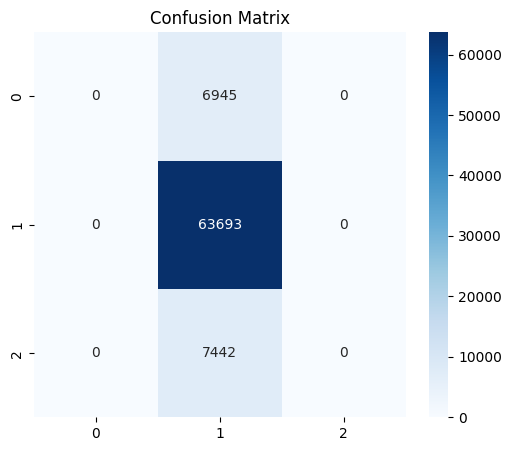


💰 --- TRADING METRICS ---
Trades: 0
Winrate: nan
Avg trade: nan
Total return: 0.0000
Sharpe (approx): nan
Max Drawdown: nan


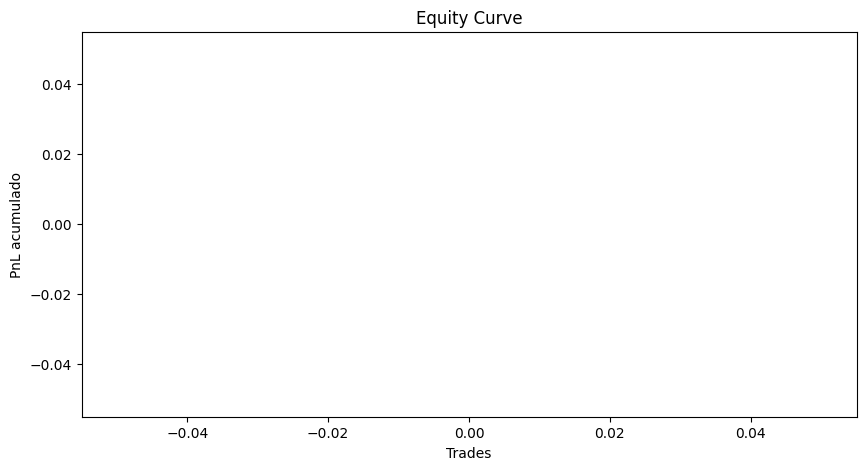


📈 --- EDGE POR SEÑAL ---
pred
1    0.0
Name: pnl, dtype: float64


{'accuracy': 0.8157402663934427,
 'winrate': nan,
 'sharpe': nan,
 'total_return': np.float64(0.0),
 'max_dd': nan}

In [ ]:
evaluate_trading_performance(result_triple_test_2)